### Ячейка 1. Импорты и загрузка

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Только стиль/палитра, без figsize
sns.set(style="whitegrid")

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (751, 214)
Test shape: (250, 211)


,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,...,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,...,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,...,0,0,0,0,0,0,0,0,0,0
3,3,6.827881,682.788051,100.000000,13.317130,13.317130,0.020658,-4.829339,0.345823,12.400000,...,0,0,1,0,0,0,0,0,0,0
4,4,2.003253,70.001455,34.943894,6.320833,6.320833,0.300347,0.300347,0.562066,60.272727,...,0,0,0,0,0,0,0,0,0,0


### Ячейка 2. Базовая информация по данным

In [5]:
# Общая информация о колонках и типах
train.info()

# Описательная статистика по таргетам
targets = ["IC50, mM", "CC50, mM", "SI"]
train[targets].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Columns: 214 entries, index to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.2 MB


,"IC50, mM","CC50, mM",SI
count,751.000000,751.000000,751.000000
mean,204.544021,577.426098,89.153313
std,370.367937,641.515163,788.882198
min,0.003517,0.700808,0.011489
25%,13.222351,99.998894,1.500000
50%,44.069306,376.580899,4.000000
75%,206.787402,877.508784,17.372463
max,4095.188563,4538.976189,15620.600000


Комментарий: здесь видно, что IC50/CC50 имеют очень широкий диапазон и сильную асимметрию (по max и quantiles), SI тоже с длинным хвостом

### Ячейка 3. Распределения таргетов + обсуждение логов

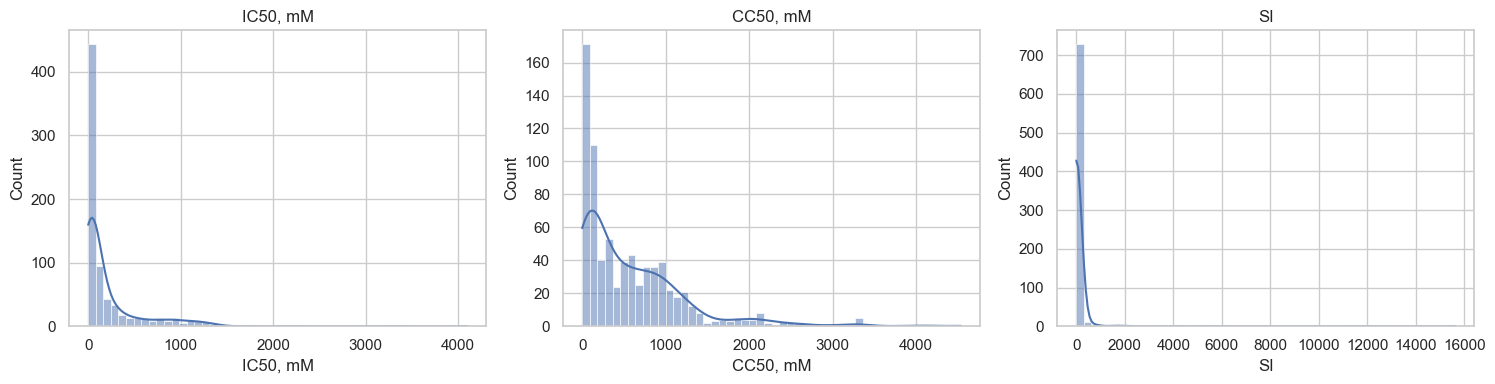

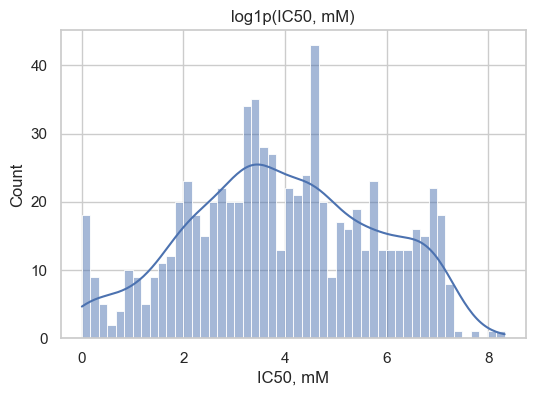

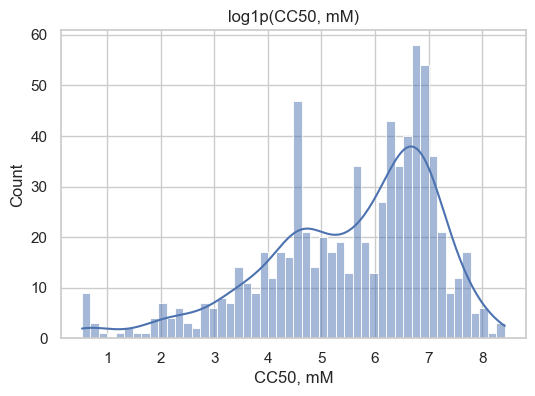

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, targets):
    sns.histplot(train[col], bins=50, kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

# Попробуем лог-распределение IC50 и CC50
for col in ["IC50, mM", "CC50, mM"]:
    plt.figure(figsize=(6, 4))
    sns.histplot(np.log1p(train[col]), bins=50, kde=True)
    plt.title(f"log1p({col})")
    plt.show()

Комментарий в ноутбуке:
– видно, что лог‑распределения более компактные, но при этом хвосты и сложная форма остаются; в итоге лог‑трансформация не дала выигрыш по RMSE (мы это эмпирически проверили — скор ~340 против ~301

### Ячейка 4. Признаки до/после arctan

In [7]:
# Описательная статистика по нескольким сырым признакам
feature_sample = train.columns[4:14]  # первые 10 дескрипторов после таргетов
train[feature_sample].describe().T

# Применим arctan и посмотрим статистику
train_atan = np.arctan(train[feature_sample])
train_atan = pd.DataFrame(train_atan, columns=feature_sample)
train_atan.describe().T

,count,mean,std,min,25%,50%,75%,max
MaxAbsEStateIndex,751.0,1.462860,0.057308,1.164130,1.459165,1.488995,1.495264,1.508118
MaxEStateIndex,751.0,1.462860,0.057308,1.164130,1.459165,1.488995,1.495264,1.508118
MinAbsEStateIndex,751.0,0.172225,0.151830,0.000039,0.048436,0.120781,0.283170,0.941867
MinEStateIndex,751.0,-0.425246,0.597480,-1.428755,-0.927474,-0.397190,0.072333,0.941867
qed,751.0,0.509877,0.170199,0.059496,0.416885,0.566810,0.638673,0.758323
SPS,751.0,1.528518,0.021922,1.466415,1.516224,1.536658,1.545079,1.554207
MolWt,751.0,1.567580,0.001167,1.561719,1.567041,1.567663,1.568360,1.569691
HeavyAtomMolWt,751.0,1.567309,0.001328,1.560804,1.566742,1.567421,1.568221,1.569629
ExactMolWt,751.0,1.567577,0.001168,1.561712,1.567037,1.567654,1.568358,1.569690
NumValenceElectrons,751.0,1.562423,0.002825,1.546991,1.560993,1.562600,1.564303,1.567939


Комментарий:
– исходные дескрипторы имеют большие разбросы и выбросы; после arctan значения сжимаются в компактный диапазон, но порядок сохраняется → деревьям проще строить сплиты, а итоговый скор стал лучше:
- без arctan + без PCA ≈ 306.7
- с arctan + без PCA ≈ 302.2

### Ячейка 5. Корреляции между признаками

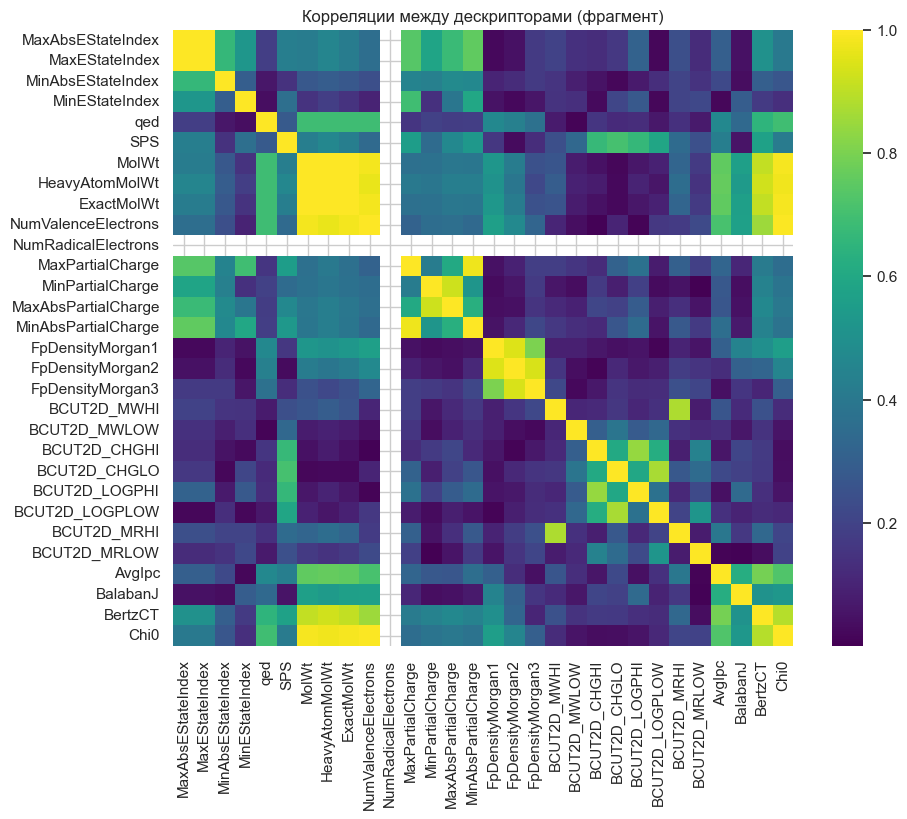

In [8]:
from itertools import islice

# Считаем матрицу корреляций по модулю для части признаков
num_features = train.columns[4:]
corr = train[num_features].corr().abs()

plt.figure(figsize=(10, 8))
sns.heatmap(corr.iloc[:30, :30], cmap="viridis")  # первые 30 фичей
plt.title("Корреляции между дескрипторами (фрагмент)")
plt.show()

Комментарий:
– видно сильные блоки высоких корреляций между дескрипторами (RDKit генерирует семейства очень похожих фич).

– это оправдывает корр‑отбор (|corr| > 0.9) в боевом пайплайне; без него модель имела бы много дублирующей информации и больше шансов переобучиться.

### Ячейка 6. Корреляция таргетов (и связь SI ≈ CC50/IC50)

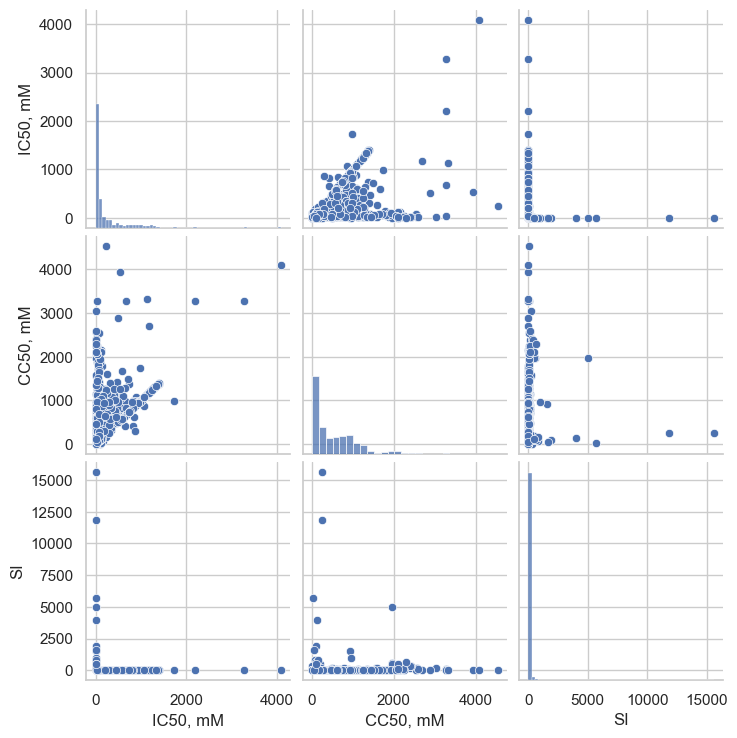

count    7.510000e+02
mean     5.927787e-14
std      8.371712e-13
min      0.000000e+00
25%      0.000000e+00
50%      4.440892e-16
75%      1.776357e-15
max      2.000888e-11
dtype: float64


In [10]:
sns.pairplot(train[targets])
plt.show()

# Проверим связь SI и отношения CC50/IC50
si_check = train["CC50, mM"] / train["IC50, mM"]
diff = (si_check - train["SI"]).abs()

print(diff.describe())

Комментарий:
– SI почти равен CC50/IC50 (разница лежит близко к нулю) → это подтверждает, что SI редундантен с IC50/CC50.

– мы сознательно продолжаем предсказывать все три таргета отдельно, чтобы не городить ручные зависимости, но это объясняет, почему улучшения по одному таргету автоматически отражаются в SI

### Ячейка 7. Сравнение успешного и неудачных решений (текстом)

Неудачные/менее удачные идеи:

PCA 80/120 компонент: давал скор 324–322 → потеря информации при сжатии, хотя матемatically аккуратен.

Лог‑таргеты IC50/CC50: вместо улучшения дали ≈340 → модель стала хуже описывать значения в исходной шкале, а RMSE в ней и считается.

Удачная комбинация:

arctan по фичам → корр‑отбор (|corr| > 0.9) → SimpleImputer + StandardScaler → LGBM без PCA, с небольшими деревьями (num_leaves=15, min_data_in_leaf=20), дала ~301 на public